# 💳 Caso 4 — Análise de Meios de Pagamento

**Objetivo:** Entender o comportamento de pagamento dos clientes e o ticket médio por forma de pagamento.

**Pergunta central:** *Clientes que parcelam mais tendem a gastar mais ou menos no total?*

---

**Conceitos de pandas praticados:**
- `pd.read_csv()` e `merge()`
- `groupby()` + `agg()` com múltiplas funções
- `pivot_table()`
- Filtros booleanos
- `sort_values()` e `nlargest()`
- Visualizações com `matplotlib`

## 📦 Célula 1 — Importar bibliotecas

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Configurações gerais de visualização
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('✅ Bibliotecas importadas com sucesso!')

✅ Bibliotecas importadas com sucesso!


## 📥 Célula 2 — Carregar os dados

Vamos carregar os arquivos diretamente do GitHub usando `pd.read_csv()` com URL.

In [2]:
BASE_URL = 'https://raw.githubusercontent.com/DeepFluxion/Mack_2026_Language_Analitycs/refs/heads/main/data/'

# Carregando os arquivos necessários
df_payments  = pd.read_csv(BASE_URL + 'olist_order_payments_dataset.csv')
df_orders    = pd.read_csv(BASE_URL + 'olist_orders_dataset.csv')
df_items     = pd.read_csv(BASE_URL + 'olist_order_items_dataset.csv')

print('Pagamentos:', df_payments.shape)
print('Pedidos:   ', df_orders.shape)
print('Itens:     ', df_items.shape)

Pagamentos: (103886, 5)
Pedidos:    (99441, 8)
Itens:      (112650, 7)


## 🔍 Célula 3 — Exploração inicial

> **Conceito:** `.head()`, `.dtypes`, `.info()` e `.describe()` são os primeiros passos para entender qualquer DataFrame.

In [3]:
# Visualizando as primeiras linhas da tabela de pagamentos
print('=== PAGAMENTOS ===')
display(df_payments.head())

print('\n=== TIPOS DE DADOS ===')
print(df_payments.dtypes)

print('\n=== ESTATÍSTICAS ===')
display(df_payments.describe())

=== PAGAMENTOS ===


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45



=== TIPOS DE DADOS ===
order_id                 object
payment_sequential        int64
payment_type             object
payment_installments      int64
payment_value           float64
dtype: object

=== ESTATÍSTICAS ===


,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


## 📊 Célula 4 — Distribuição dos meios de pagamento

> **Conceito:** `value_counts()` conta a frequência de cada valor único em uma coluna. Ideal para variáveis categóricas.

Quantidade de transações por tipo de pagamento:
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64


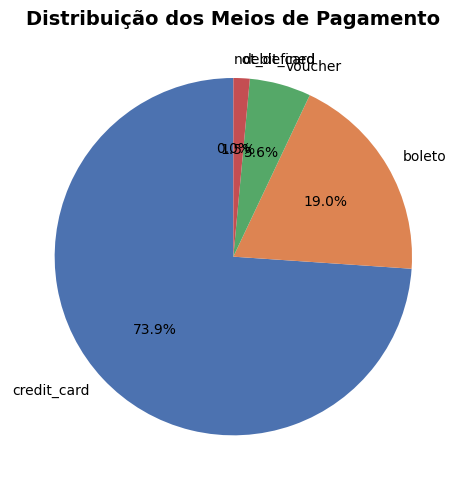

In [4]:
# Contando quantas transações foram feitas por cada meio de pagamento
contagem_tipo = df_payments['payment_type'].value_counts()

print('Quantidade de transações por tipo de pagamento:')
print(contagem_tipo)

# Gráfico de pizza
fig, ax = plt.subplots()
ax.pie(
    contagem_tipo,
    labels=contagem_tipo.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#4C72B0', '#DD8452', '#55A868', '#C44E52']
)
ax.set_title('Distribuição dos Meios de Pagamento', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 💰 Célula 5 — Ticket médio por meio de pagamento

> **Conceito:** `groupby()` agrupa linhas com o mesmo valor em uma coluna. `agg()` permite aplicar múltiplas funções de uma vez (soma, média, contagem).

Resumo por Meio de Pagamento:


,total_transacoes,valor_total,ticket_medio,parcelas_media
payment_type,,,,
credit_card,76795,12542084.19,163.32,3.51
boleto,19784,2869361.27,145.03,1.00
voucher,5775,379436.87,65.70,1.00
debit_card,1529,217989.79,142.57,1.00
not_defined,3,0.00,0.00,1.00


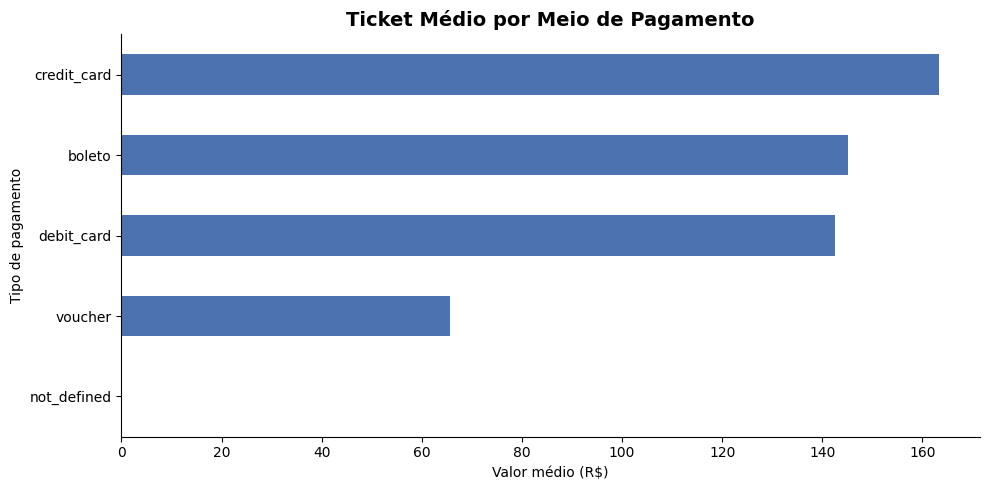

In [5]:
# Agrupando por tipo de pagamento e calculando métricas
resumo_pagamento = (
    df_payments
    .groupby('payment_type')
    .agg(
        total_transacoes  = ('order_id',       'count'),
        valor_total       = ('payment_value',  'sum'),
        ticket_medio      = ('payment_value',  'mean'),
        parcelas_media    = ('payment_installments', 'mean')
    )
    .round(2)
    .sort_values('valor_total', ascending=False)
)

print('Resumo por Meio de Pagamento:')
display(resumo_pagamento)

# Gráfico de barras — ticket médio
fig, ax = plt.subplots()
resumo_pagamento['ticket_medio'].sort_values().plot(
    kind='barh', ax=ax, color='#4C72B0'
)
ax.set_title('Ticket Médio por Meio de Pagamento', fontsize=14, fontweight='bold')
ax.set_xlabel('Valor médio (R$)')
ax.set_ylabel('Tipo de pagamento')
plt.tight_layout()
plt.show()

## 🔎 Célula 6 — Filtro: apenas cartão de crédito

> **Conceito:** Filtro booleano — `df[condição]` retorna apenas as linhas onde a condição é `True`.

In [6]:
# Filtrando apenas pagamentos no cartão de crédito
df_cartao = df_payments[df_payments['payment_type'] == 'credit_card'].copy()

print(f'Total de pedidos no cartão de crédito: {len(df_cartao):,}')
print(f'Número máximo de parcelas: {df_cartao["payment_installments"].max()}')
print(f'\nDistribuição por número de parcelas:')
print(df_cartao['payment_installments'].value_counts().sort_index())

Total de pedidos no cartão de crédito: 76,795
Número máximo de parcelas: 24

Distribuição por número de parcelas:
payment_installments
0         2
1     25455
2     12413
3     10461
4      7098
5      5239
6      3920
7      1626
8      4268
9       644
10     5328
11       23
12      133
13       16
14       15
15       74
16        5
17        8
18       27
20       17
21        3
22        1
23        1
24       18
Name: count, dtype: int64


## 📈 Célula 7 — Parcelamento vs. Valor gasto

> **Conceito:** `groupby()` + `mean()` para ver a média de valor por número de parcelas. Responde à pergunta principal do estudo.

,payment_installments,valor_medio,quantidade
1,1,95.872930,25455
2,2,127.228150,12413
3,3,142.539317,10461
4,4,163.976840,7098
5,5,183.465222,5239
6,6,209.849952,3920
7,7,187.673672,1626
8,8,307.737427,4268
9,9,203.440870,644
10,10,415.085837,5328


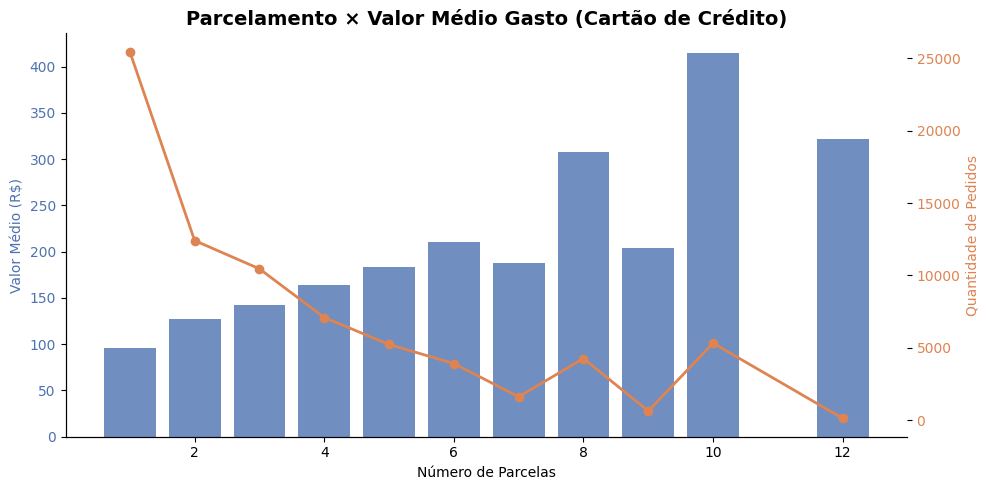


💡 Conclusão: quanto mais parcelas, maior ou menor o gasto médio?


In [7]:
# Valor médio por número de parcelas (apenas cartão de crédito)
parcelamento = (
    df_cartao
    .groupby('payment_installments')['payment_value']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'valor_medio', 'count': 'quantidade'})
    .reset_index()
)

# Removendo parcelas com poucos registros (menos de 100)
parcelamento = parcelamento[parcelamento['quantidade'] >= 100]

display(parcelamento)

# Gráfico: parcelas x valor médio
fig, ax1 = plt.subplots()

cor1 = '#4C72B0'
cor2 = '#DD8452'

ax1.bar(parcelamento['payment_installments'], parcelamento['valor_medio'], color=cor1, alpha=0.8, label='Valor médio (R$)')
ax1.set_xlabel('Número de Parcelas')
ax1.set_ylabel('Valor Médio (R$)', color=cor1)
ax1.tick_params(axis='y', labelcolor=cor1)

ax2 = ax1.twinx()
ax2.plot(parcelamento['payment_installments'], parcelamento['quantidade'], color=cor2, marker='o', linewidth=2, label='Quantidade')
ax2.set_ylabel('Quantidade de Pedidos', color=cor2)
ax2.tick_params(axis='y', labelcolor=cor2)

plt.title('Parcelamento × Valor Médio Gasto (Cartão de Crédito)', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

print('\n💡 Conclusão: quanto mais parcelas, maior ou menor o gasto médio?')

## 🧩 Célula 8 — Pivot Table: tipo de pagamento × faixa de parcelas

> **Conceito:** `pd.cut()` cria faixas/categorias a partir de valores numéricos. `pivot_table()` é o equivalente a uma tabela dinâmica do Excel.

In [8]:
# Criando faixas de parcelamento com pd.cut()
df_payments_copy = df_payments.copy()
df_payments_copy['faixa_parcelas'] = pd.cut(
    df_payments_copy['payment_installments'],
    bins=[0, 1, 3, 6, 12, 24],
    labels=['À vista', '2-3x', '4-6x', '7-12x', '13-24x']
)

# Pivot table: tipo de pagamento × faixa de parcelas → valor médio
tabela = pd.pivot_table(
    df_payments_copy,
    values='payment_value',
    index='payment_type',
    columns='faixa_parcelas',
    aggfunc='mean'
).round(2)

print('Valor médio por tipo de pagamento e faixa de parcelas:')
display(tabela)

Valor médio por tipo de pagamento e faixa de parcelas:


/tmp/ipykernel_4757/930130769.py:10: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tabela = pd.pivot_table(


faixa_parcelas,À vista,2-3x,4-6x,7-12x,13-24x
payment_type,,,,,
boleto,145.03,NaN,NaN,NaN,NaN
credit_card,95.87,134.23,181.32,333.29,413.72
debit_card,142.57,NaN,NaN,NaN,NaN
not_defined,0.00,NaN,NaN,NaN,NaN
voucher,65.70,NaN,NaN,NaN,NaN


## 🏆 Célula 9 — Top 10 maiores pedidos

> **Conceito:** `nlargest()` retorna as N maiores linhas de uma coluna. Muito mais direto que `sort_values().head()`.

In [9]:
# Os 10 maiores valores de pagamento
top10 = df_payments.nlargest(10, 'payment_value')[['order_id', 'payment_type', 'payment_installments', 'payment_value']]

print('Top 10 maiores pagamentos:')
display(top10)

Top 10 maiores pagamentos:


,order_id,payment_type,payment_installments,payment_value
52107,03caa2c082116e1d31e67e9ae3700499,credit_card,1,13664.08
34370,736e1922ae60d0d6a89247b851902527,boleto,1,7274.88
41419,0812eb902a67711a1cb742b3cdaa65ae,credit_card,8,6929.31
49581,fefacc66af859508bf1a7934eab1e97f,boleto,1,6922.21
85539,f5136e38d1a14a4dbd87dff67da82701,boleto,1,6726.66
62409,2cc9089445046817a7539d90805e6e5a,boleto,1,6081.54
43232,a96610ab360d42a2e5335a3998b4718a,credit_card,10,4950.34
70320,b4c4b76c642808cbe472a32b86cddc95,credit_card,5,4809.44
6440,199af31afc78c699f0dbf71fb178d4d4,credit_card,8,4764.34
67546,8dbc85d1447242f3b127dda390d56e19,credit_card,8,4681.78


## ✅ Célula 10 — Conclusões

Responda as perguntas abaixo com base nos resultados obtidos:

In [10]:
print('=== RESUMO FINAL ===')
print()

meio_mais_usado = df_payments['payment_type'].value_counts().idxmax()
maior_ticket    = resumo_pagamento['ticket_medio'].idxmax()
media_parcelas  = df_cartao['payment_installments'].mean()

print(f'💳 Meio de pagamento mais usado:        {meio_mais_usado}')
print(f'💰 Meio com maior ticket médio:         {maior_ticket}')
print(f'📦 Média de parcelas no cartão:         {media_parcelas:.1f}x')
print()
print('📌 Resposta à pergunta central:')

correlacao = df_cartao[['payment_installments', 'payment_value']].corr().iloc[0, 1]
print(f'   Correlação entre parcelas e valor gasto: {correlacao:.3f}')
if correlacao > 0:
    print('   → Clientes que parcelam mais GASTAM MAIS no total.')
else:
    print('   → Clientes que parcelam mais GASTAM MENOS no total.')

=== RESUMO FINAL ===

💳 Meio de pagamento mais usado:        credit_card
💰 Meio com maior ticket médio:         credit_card
📦 Média de parcelas no cartão:         3.5x

📌 Resposta à pergunta central:
   Correlação entre parcelas e valor gasto: 0.376
   → Clientes que parcelam mais GASTAM MAIS no total.
